https://velog.io/@woooa/TIL-%EB%B2%A0%EC%9D%B4%EC%A6%88-%EC%A0%95%EB%A6%AC

https://ablearn.kr/insight/?bmode=view&idx=13428641

In [13]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.naive_bayes import CategoricalNB


def draw_bayes_square(df):

    # -------------------
    # 자동 분리
    # -------------------

    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]

    feature = X.columns[0]
    target = y.name

    # -------------------
    # 학습
    # -------------------

    model = CategoricalNB(alpha=0)

    model.fit(X, y)

    # -------------------
    # 확률
    # -------------------

    prior = np.exp(
        model.class_log_prior_
    )

    p_y0 = prior[0]
    p_y1 = prior[1]

    cond = np.exp(
        model.feature_log_prob_[0]
    )

    p_x0_y0 = cond[0][0]
    p_x1_y0 = cond[0][1]

    p_x0_y1 = cond[1][0]
    p_x1_y1 = cond[1][1]

    # -------------------
    # 면적
    # -------------------

    areas = [

        p_y1 * p_x1_y1,
        p_y1 * p_x0_y1,

        p_y0 * p_x1_y0,
        p_y0 * p_x0_y0
    ]

    sns.set_theme(style="white")

    fig, ax = plt.subplots(
        figsize=(9, 9)
    )

    colors = sns.color_palette(
        "pastel",
        4
    )

    boxes = [

        (
            (0, p_x0_y1),
            p_y1,
            p_x1_y1,
            colors[0],
            f"{target}=1\n{feature}=1\n{areas[0]:.2f}"
        ),

        (
            (0, 0),
            p_y1,
            p_x0_y1,
            colors[1],
            f"{target}=1\n{feature}=0\n{areas[1]:.2f}"
        ),

        (
            (p_y1, p_x0_y0),
            p_y0,
            p_x1_y0,
            colors[2],
            f"{target}=0\n{feature}=1\n{areas[2]:.2f}"
        ),

        (
            (p_y1, 0),
            p_y0,
            p_x0_y0,
            colors[3],
            f"{target}=0\n{feature}=0\n{areas[3]:.2f}"
        )
    ]

    for pos, w, h, color, txt in boxes:

        ax.add_patch(

            Rectangle(
                pos,
                w,
                h,
                facecolor=color,
                edgecolor="black",
                linewidth=3
            )

        )

        ax.text(
            pos[0] + w/2,
            pos[1] + h/2,
            txt,
            ha="center",
            va="center",
            fontsize=13
        )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_title(
        f"{feature} x {target}"
    )

    plt.show()

In [10]:
import pandas as pd
from sklearn.naive_bayes import BernoulliNB

# -----------------
# 데이터 생성
# travel
# 1 = 여행
# 0 = 비여행
# like
# 1 = 좋아요
# 0 = 싫어요
# -----------------

# import pandas as pd

# df = pd.DataFrame({

# "평가": [
# "좋아요","좋아요","좋아요","좋아요","좋아요",
# "좋아요","좋아요","좋아요","좋아요","좋아요",
# "싫어요","싫어요","싫어요","싫어요","싫어요",
# "싫어요","싫어요","싫어요","싫어요","싫어요"
# ],

# "콘텐츠": [
# "여행","여행","여행","여행","여행",
# "여행","여행","여행","비여행","비여행",
# "여행","여행","여행","여행",
# "비여행","비여행","비여행",
# "비여행","비여행","비여행"
# ]

# })

# print(df)

df = pd.DataFrame({
    "travel": [1,1,1,1,1,1,1,1,0,0,  1,1,1,1,0,0,0,0,0,0],
    "like":   [1,1,1,1,1,1,1,1,1,1,  0,0,0,0,0,0,0,0,0,0]  # 사전확률
})

print(df)

    travel  like
0        1     1
1        1     1
2        1     1
3        1     1
4        1     1
5        1     1
6        1     1
7        1     1
8        0     1
9        0     1
10       1     0
11       1     0
12       1     0
13       1     0
14       0     0
15       0     0
16       0     0
17       0     0
18       0     0
19       0     0


In [11]:
x = df[["travel"]]
y = df["like"]

model = BernoulliNB(alpha=0) # 라플라스 스무딩

model.fit(x,y)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[10.,10.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Log probability of each class (smoothed).","ndarray[float64](2,)","[-0.69,-0.69]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 1)","[[4.], [8.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of features given a class, P(x_i|y).","ndarray[float64](2, 1)","[[-0.92], [-0.22]]"


[[0.33333333 0.66666667]]


c:\Users\user\.conda\envs\env_ds\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(
c:\Users\user\.conda\envs\env_ds\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(


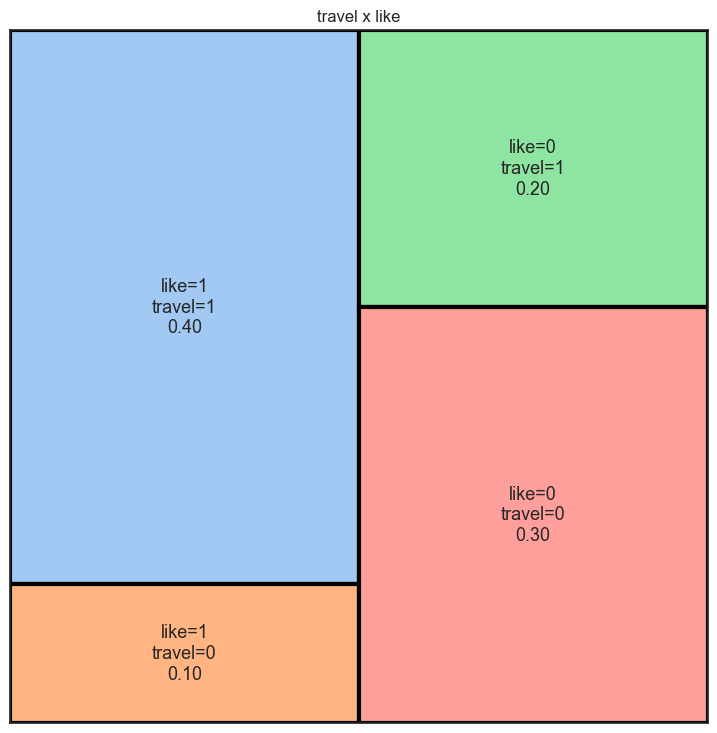

In [14]:
# 예측

# 여행 콘텐츠일때 좋아할 확률
model.predict([[1]])
# [1] => 좋아요 예측

prob = model.predict_proba([[1]])

print(prob)  # 확률 보기 
# [[0.35714286 0.64285714]]

# P(👍∣🛫)=66.7%

draw_bayes_square(df)

In [15]:
import pandas as pd
from sklearn.naive_bayes import BernoulliNB


# -------------------------
# 음식 데이터
# spicy
# 1 = 매움
# 0 = 안매움
#
# like
# 1 = 좋아함
# 0 = 싫어함
# -------------------------

df = pd.DataFrame({

    "spicy":[
        1,1,1,1,1,1,1,1,1,0,
        1,1,1,1,0,0,0,0,0,0
    ],

    "like":[
        1,1,1,1,1,1,1,1,1,1,
        0,0,0,0,0,0,0,0,0,0
    ]

})

print(df)

    spicy  like
0       1     1
1       1     1
2       1     1
3       1     1
4       1     1
5       1     1
6       1     1
7       1     1
8       1     1
9       0     1
10      1     0
11      1     0
12      1     0
13      1     0
14      0     0
15      0     0
16      0     0
17      0     0
18      0     0
19      0     0


In [16]:
x = df[["spicy"]]
y = df["like"]

model = BernoulliNB(alpha=0) # 라플라스 스무딩

model.fit(x,y)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[10.,10.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Log probability of each class (smoothed).","ndarray[float64](2,)","[-0.69,-0.69]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 1)","[[4.], [9.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of features given a class, P(x_i|y).","ndarray[float64](2, 1)","[[-0.92], [-0.11]]"


예측 [1]
확률 [[0.30769231 0.69230769]]


c:\Users\user\.conda\envs\env_ds\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(
c:\Users\user\.conda\envs\env_ds\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(
c:\Users\user\.conda\envs\env_ds\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(


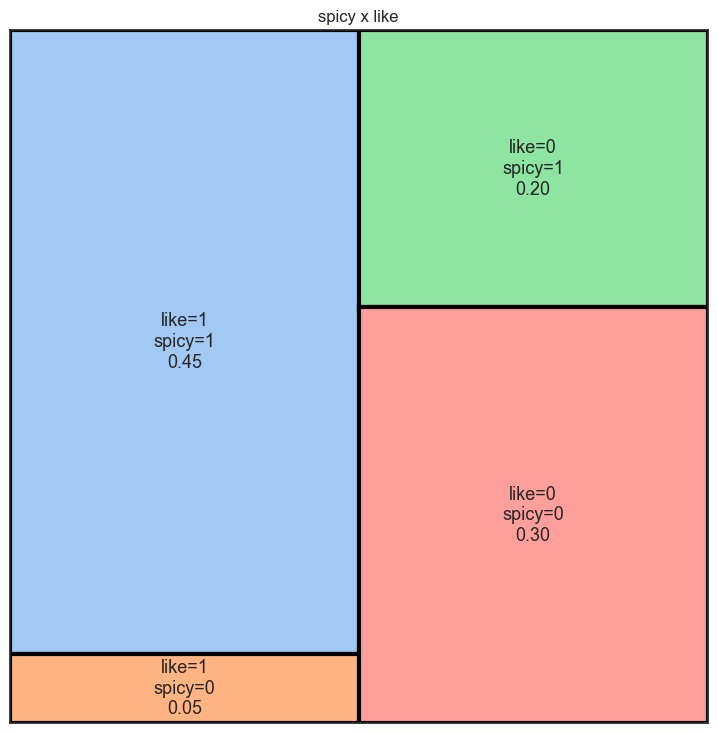

In [ ]:
# 예측

# 매운 음식일때 좋아할 확률
model.predict([[1]])
# [1] => 좋아요 예측

pred = model.predict([[1]])
prob = model.predict_proba([[1]])

print("예측",pred)
print("확률",prob)

# 매운 음식 추천

# 싫어할 확률 → 31%
# 좋아할 확률 → 69%

draw_bayes_square(df)